In [1]:
%load_ext autoreload
%autoreload 2

In [29]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID" # Ensures IDs match nvidia-smi
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

import random
from pathlib import Path

import numpy as np
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import transforms

from PIL import Image

from preprocessing_module import find_class_names_filenames, stratified_split_data_paths, NatureCityScenesDataset
from trainer_class import Trainer

from ResNet import ResNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def plot_metrics(class_names, num_epochs, results_dict, title_str, savefile=None):

    epochs_list = np.arange(1, num_epochs+1)

    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.plot(epochs_list, results_dict["train_loss"], '.-', label="train loss")
    plt.plot(epochs_list, results_dict["val_loss"], '.-', label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()    

    plt.subplot(2, 2, 2)
    plt.plot(epochs_list, results_dict["train_acc"], '.-', label="train acc")
    plt.plot(epochs_list, results_dict["val_acc"], '.-', label="val acc")
    plt.plot(epochs_list, results_dict["val_mAP"], '.-', label="val mAP")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(2, 2, 3) 
    hist_arr_val_acc_per_class = np.asarray(results_dict["val_acc_per_class"])
    for class_number, class_name in enumerate(class_names):
        plt.plot(epochs_list, hist_arr_val_acc_per_class[:, class_number], ".-", label=f"Class {class_number}: {class_name}")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy, validation set")
    plt.legend()


    plt.subplot(2, 2, 4) 
    hist_arr_val_AP_per_class = np.asarray(results_dict["val_AP_per_class"])
    for class_number, class_name in enumerate(class_names):
        plt.plot(epochs_list, hist_arr_val_AP_per_class[:, class_number], ".-", label=f"Class {class_number}: {class_name}")

    plt.xlabel("Epoch")
    plt.ylabel("Average precision, validation set")
    plt.legend()
     
    plt.suptitle(title_str, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if savefile:
        plt.savefig(savefile, bbox_inches="tight")
    
    plt.show()

Device: cuda


In [31]:
set_seed(42)

DATASET_PATH = r"/itf-fi-ml/shared/courses/IN3310/mandatory1_data"

class_names, class_filenames = find_class_names_filenames(DATASET_PATH)
x_train_paths, x_val_paths, x_test_paths, y_train, y_val, y_test = stratified_split_data_paths(class_names, class_filenames)

transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = NatureCityScenesDataset(DATASET_PATH, x_train_paths, y_train, transform=transform)
val_set = NatureCityScenesDataset(DATASET_PATH, x_val_paths, y_val, transform=transform)
test_set = NatureCityScenesDataset(DATASET_PATH, x_test_paths, y_test, transform=transform)

# --------------------------------------------------------------------------------------------------------------------------------

BATCH_SIZE = 64
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

def batch_noise_augment(images: torch.Tensor, std: float = 0.03) -> torch.Tensor:
    noise = torch.randn_like(images) * std
    return torch.clamp(images + noise, -1.0, 1.0)

# --------------------------------------------------------------------------------------------------------------------------------


In [ ]:
model_ResNet = ResNet(img_channels=3, num_layers=18, num_classes=6).to(device)

num_epochs = 8

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ResNet.parameters(), lr=1e-4)

trainer_ResNet = Trainer(
    model=model_ResNet,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_name="ResNet",
    augment_fn=lambda x: batch_noise_augment(x, std=0.02),
)

trainer_ResNet.fit(train_loader, val_loader, epochs=num_epochs)

trainer_ResNet.evaluate(test_loader)

# Move results from GPU to memory
results_dict = trainer_ResNet.history

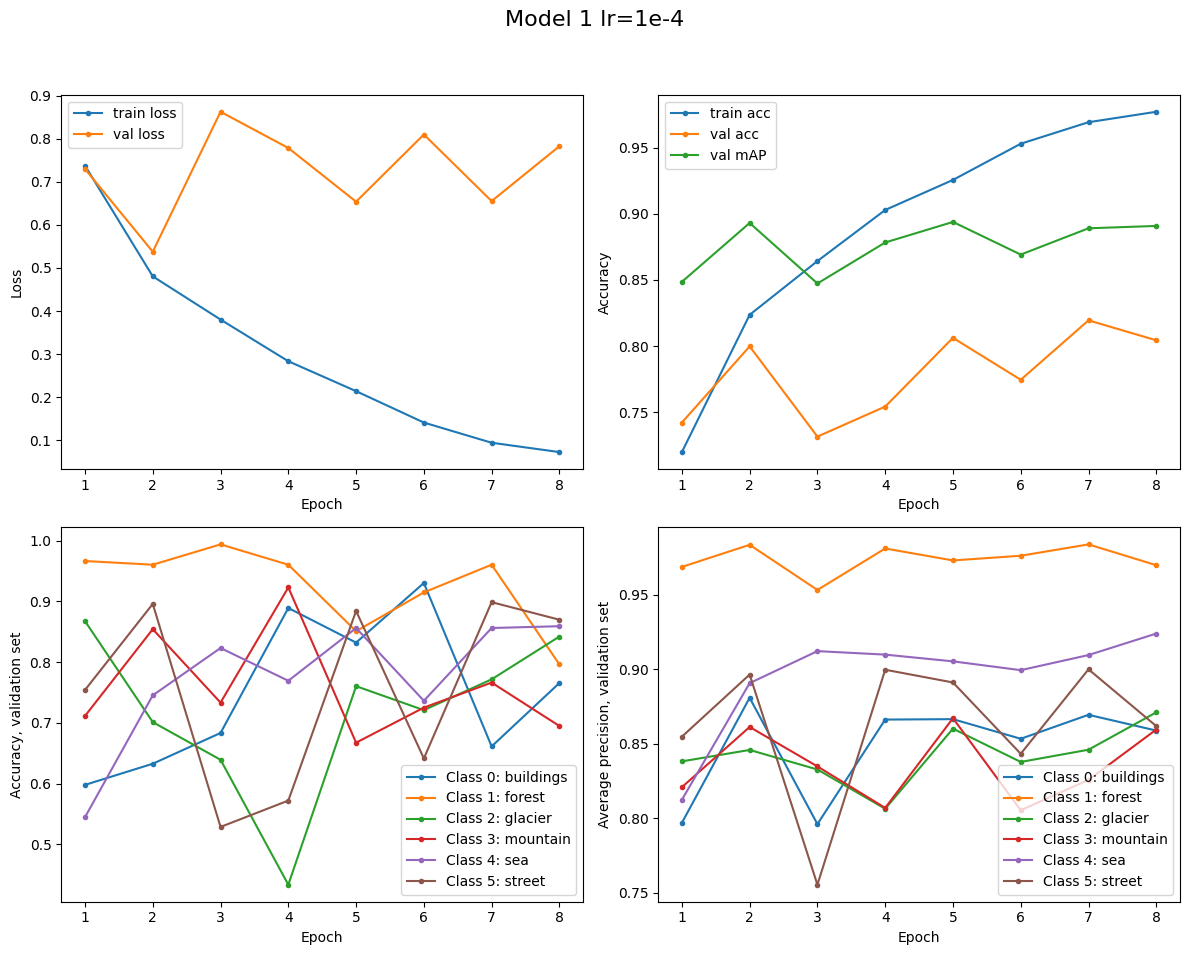

In [ ]:
plot_metrics(class_names, num_epochs, results_dict, f"Model 1, lr=1e-4")

In [ ]:
# ResNet model 2:

model_ResNet18_2 = ResNet(img_channels=3, num_layers=18, num_classes=6).to(device)

num_epochs = 8

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ResNet18_2.parameters(), lr=1e-4)

trainer_ResNet18_2 = Trainer(
    model=model_ResNet,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_name="ResNet18_2_lr00001_std01",
    augment_fn=lambda x: batch_noise_augment(x, std=0.05),
)

trainer_ResNet18_2.fit(train_loader, val_loader, epochs=num_epochs)

trainer_ResNet18_2.evaluate(test_loader)

# Move results from GPU to memory
results_dict_2 = trainer_ResNet18_2.history

Epoch 01 | train loss: 0.0973, acc: 0.968 | val loss: 0.7775, acc: 0.804, acc_per_class: [0.81962025 0.83890575 0.7070423  0.78296703 0.88922155 0.79479766], mean average precision (mAP): 0.886, AP per class: [0.86475152 0.98167049 0.84965484 0.85304627 0.9104656  0.85895528]
Epoch 02 | train loss: 0.1009, acc: 0.965 | val loss: 0.8049, acc: 0.800, acc_per_class: [0.8164557  0.80851066 0.70985913 0.77747256 0.88622755 0.80924857], mean average precision (mAP): 0.884, AP per class: [0.86291123 0.97882485 0.84896679 0.851873   0.91042296 0.85110014]
Epoch 03 | train loss: 0.0970, acc: 0.966 | val loss: 0.8002, acc: 0.801, acc_per_class: [0.806962   0.8267477  0.70140845 0.74450547 0.9011976  0.83815026], mean average precision (mAP): 0.885, AP per class: [0.86142446 0.97923007 0.84977697 0.85194515 0.90836699 0.85910591]
Epoch 04 | train loss: 0.0982, acc: 0.968 | val loss: 0.8004, acc: 0.801, acc_per_class: [0.8164557  0.81762916 0.70985913 0.76373625 0.89221555 0.8150289 ], mean averag

Epoch 01 | train loss: 0.0603, acc: 0.981 | val loss: 0.6691, acc: 0.829, acc_per_class: [0.76582277 0.9118541  0.7859155  0.77472526 0.88622755 0.8526012 ], mean average precision (mAP): 0.899, AP per class: [0.87138355 0.98497089 0.86287521 0.86124293 0.92392872 0.88694218]
Epoch 02 | train loss: 0.0549, acc: 0.983 | val loss: 0.6745, acc: 0.822, acc_per_class: [0.8006329  0.887538   0.7774648  0.7582418  0.8742515  0.84393066], mean average precision (mAP): 0.898, AP per class: [0.86867688 0.98353702 0.86686569 0.86321622 0.92387347 0.8808823 ]
Epoch 03 | train loss: 0.0562, acc: 0.984 | val loss: 0.6752, acc: 0.825, acc_per_class: [0.7848101  0.8966565  0.7746479  0.77472526 0.8772455  0.84682083], mean average precision (mAP): 0.898, AP per class: [0.8690099  0.9837919  0.86534643 0.86339698 0.92517429 0.88414741]
Epoch 04 | train loss: 0.0557, acc: 0.984 | val loss: 0.6750, acc: 0.823, acc_per_class: [0.79746836 0.8844985  0.7746479  0.760989   0.88323355 0.84393066], mean averag

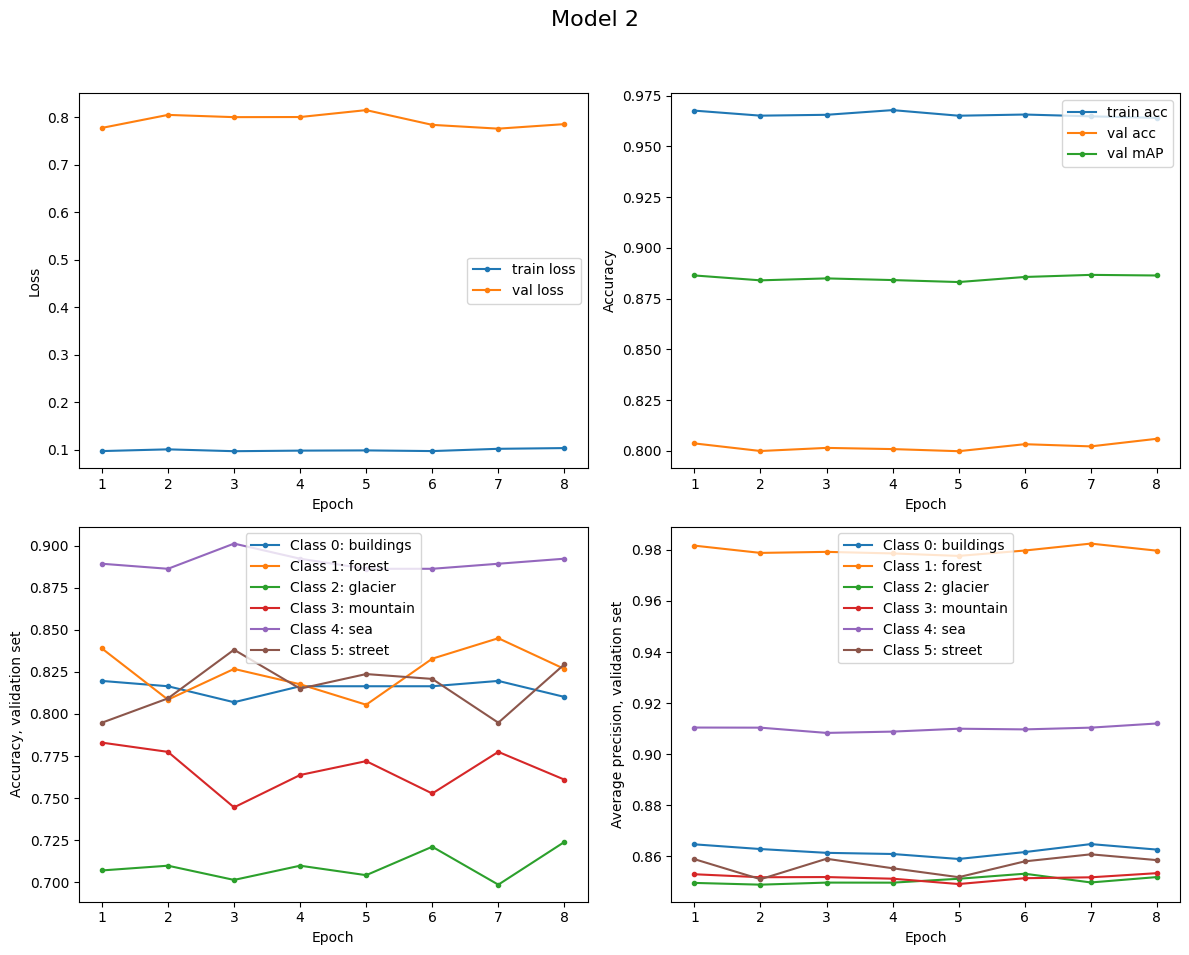

In [ ]:
plot_metrics(class_names, num_epochs, results_dict_2, "Model 2")

In [11]:
# ResNet model 3:

model_ResNet18_3 = ResNet(img_channels=3, num_layers=18, num_classes=6).to(device)

num_epochs = 8

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ResNet18_3.parameters(), lr=1e-3)

trainer_ResNet18_3 = Trainer(
    model=model_ResNet,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_name="ResNet18_3_lr001_std01",
    augment_fn=lambda x: batch_noise_augment(x, std=0.1),
)

trainer_ResNet18_3.fit(train_loader, val_loader, epochs=num_epochs)

# Move results from GPU to memory
results_dict_3 = trainer_ResNet18_3.history

Epoch 01 | train loss: 0.0985, acc: 0.968 | val loss: 0.7844, acc: 0.800, acc_per_class: [0.8164557  0.8267477  0.7070423  0.76648355 0.89221555 0.80057806], mean average precision (mAP): 0.885, AP per class: [0.86307141 0.981096   0.84862736 0.85227923 0.91030291 0.85715099]
Epoch 02 | train loss: 0.0996, acc: 0.966 | val loss: 0.7702, acc: 0.809, acc_per_class: [0.8006329  0.8541033  0.70140845 0.7692308  0.88323355 0.85549134], mean average precision (mAP): 0.888, AP per class: [0.85903777 0.9805152  0.85445312 0.85451419 0.90926294 0.86898252]
Epoch 03 | train loss: 0.1016, acc: 0.965 | val loss: 0.7906, acc: 0.797, acc_per_class: [0.8101266  0.8145897  0.7070423  0.74725276 0.89221555 0.8179191 ], mean average precision (mAP): 0.885, AP per class: [0.86178384 0.97927124 0.84956678 0.8523991  0.90993692 0.85649397]


Exception ignored in: <function _releaseLock at 0x7fe09bab14e0>
Traceback (most recent call last):
  File "/storage/software/Python/3.12.3-GCCcore-13.3.0/lib/python3.12/logging/__init__.py", line 243, in _releaseLock
    def _releaseLock():
    
KeyboardInterrupt: 


Epoch 04 | train loss: 0.1033, acc: 0.966 | val loss: 0.7831, acc: 0.804, acc_per_class: [0.81962025 0.8541033  0.6957747  0.7582418  0.8982036  0.81213874], mean average precision (mAP): 0.886, AP per class: [0.86303212 0.98199122 0.85005992 0.85091597 0.90768223 0.86211227]


KeyboardInterrupt: 

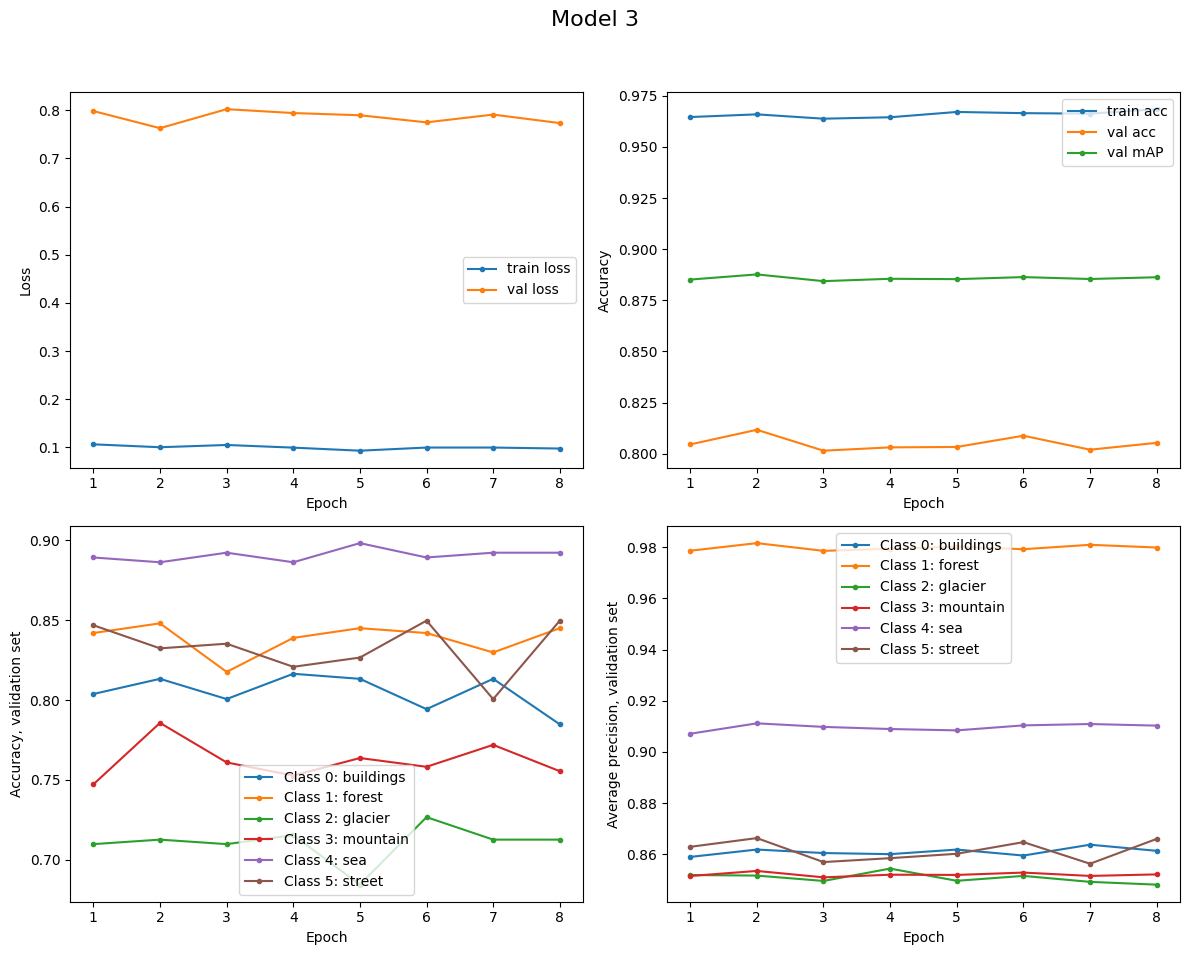

In [8]:
plot_metrics(class_names, num_epochs, results_dict_3, "Model 3")

In [ ]:
# Imported pretrained ResNet18 model from torchvision
# Change from 1000 to 6 outputs in last layer
model_torch_ResNet18 = torchvision.models.resnet18(weights="ResNet18_Weights.DEFAULT")
num_features = model_torch_ResNet18.fc.in_features
print(model_torch_ResNet18.fc.out_features)
model_torch_ResNet18.fc = nn.Linear(num_features, 6)
print(model_torch_ResNet18.fc.out_features)

1000
6


In [33]:
num_epochs = 8

model_torch_ResNet18.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_torch_ResNet18.parameters(), lr=1e-4)

trainer_model_torch_ResNet18 = Trainer(
    model=model_torch_ResNet18,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    run_name="torch_ResNet18_lr00001_std002_best_weights",
    augment_fn=lambda x: batch_noise_augment(x, std=0.02),
)

trainer_model_torch_ResNet18.fit(train_loader, val_loader, epochs=num_epochs)

# Move results from GPU to memory
results_dict_torch_ResNet18 = trainer_model_torch_ResNet18.history

Epoch 01 | train loss: 0.3087, acc: 0.892 | val loss: 0.2099, acc: 0.931, acc_per_class: [0.95253164 0.99696046 0.8056338  0.9203297  0.98802394 0.93352604], mean average precision (mAP): 0.973, AP per class: [0.97482686 0.99991034 0.94479758 0.94248389 0.99410664 0.98225601]
Epoch 02 | train loss: 0.0919, acc: 0.971 | val loss: 0.2447, acc: 0.920, acc_per_class: [0.95253164 0.99088144 0.7971831  0.91483516 0.97604793 0.89884394], mean average precision (mAP): 0.966, AP per class: [0.9654024  0.99977639 0.92528979 0.93258556 0.99214562 0.98245488]
Epoch 03 | train loss: 0.0344, acc: 0.990 | val loss: 0.2632, acc: 0.929, acc_per_class: [0.9113924  0.993921   0.87323946 0.86538464 0.97604793 0.95953757], mean average precision (mAP): 0.968, AP per class: [0.97552746 0.99985399 0.92831145 0.93114885 0.99457923 0.97978084]
Epoch 04 | train loss: 0.0246, acc: 0.994 | val loss: 0.3080, acc: 0.924, acc_per_class: [0.95253164 0.99696046 0.8197183  0.8818681  0.98802394 0.91618496], mean averag

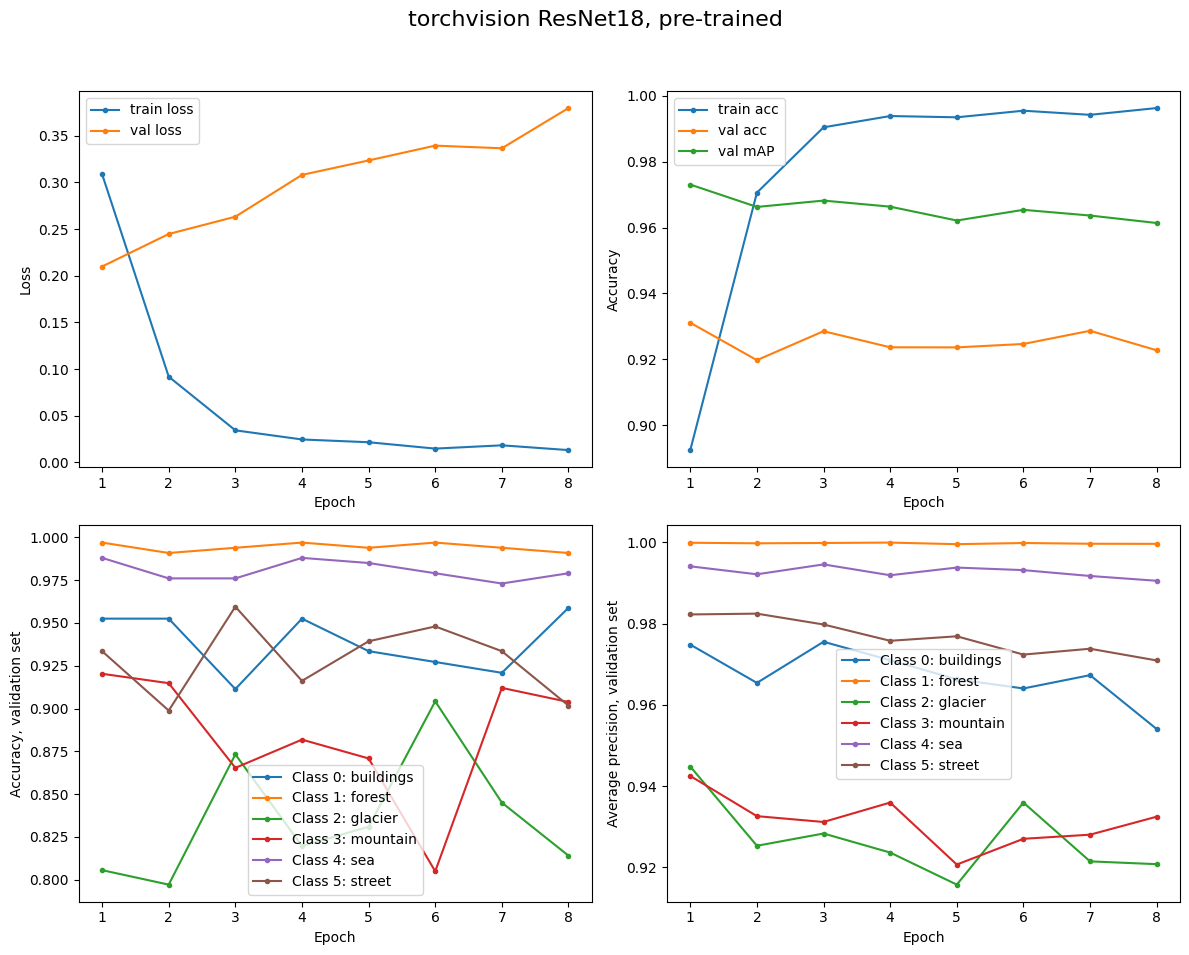

In [34]:
plot_metrics(class_names, num_epochs, results_dict_torch_ResNet18, "torchvision ResNet18, pre-trained")